In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

c:\Users\Felipe Novais\.conda\envs\data_jobs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 - Locations with most job postings

In [2]:
# general data filtering
df_da_us = df.loc[
    (df["job_country"] == "United States") & (df["job_title_short"] == "Data Analyst"),
    :
].copy()

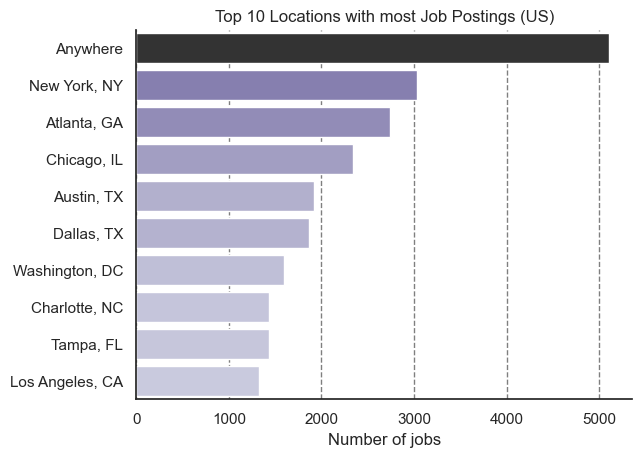

In [3]:
# aggregate data for job locations
location_count = df_da_us["job_location"].value_counts().head(10).to_frame()

# setting custom params form customization
custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False,
}
sns.set_theme(
    style="white",
    rc=custom_params
)

# plotting
sns.barplot(
    data=location_count,
    x="count",
    y="job_location",
    hue="count",
    palette="Purples_d",
    legend=False
)

plt.grid(True, linestyle="--", color="black", alpha=0.5)
plt.grid(False, axis="y")
plt.ylabel("")
plt.xlabel("Number of jobs")
plt.title("Top 10 Locations with most Job Postings (US)")
plt.show()

## 2 - WFH, Degree Requirement and Health Insurance

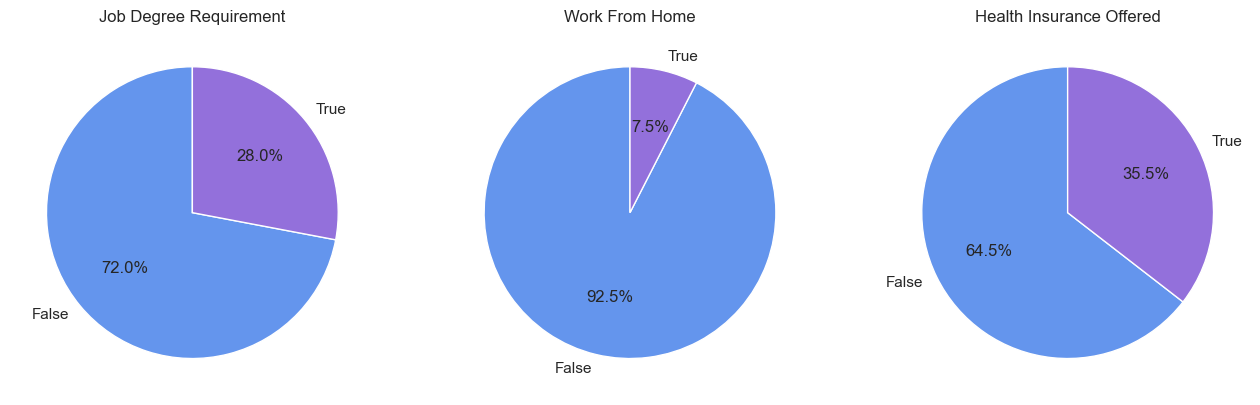

In [4]:
# set up dictionary for plot loop
pie_charts_data = {
    "job_no_degree_mention":"Job Degree Requirement",
    "job_work_from_home":"Work From Home",
    "job_health_insurance":"Health Insurance Offered",
}

fig, ax = plt.subplots(ncols=3)

for i, (column, title) in enumerate(pie_charts_data.items()):
    df_da_us.loc[
        :,
        column
    ].value_counts().plot(kind="pie", ax=ax[i], figsize=(16, 5), startangle=90, autopct="%1.1f%%", colors=["cornflowerblue", "mediumpurple"])

    ax[i].set_title(title)

plt.show()

## 3 - Top companies with more job postings

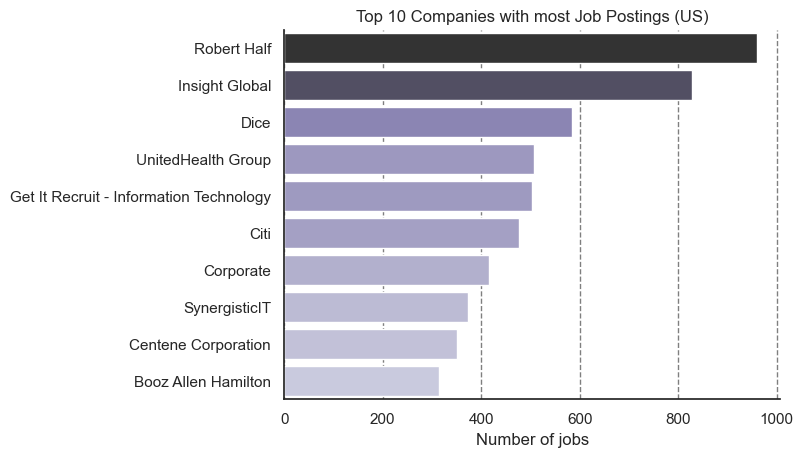

In [5]:
companies_count = df_da_us["company_name"].value_counts().head(10).to_frame()

sns.barplot(
    data=companies_count,
    x="count",
    y="company_name",
    hue="count",
    palette="Purples_d",
    legend=False
)

plt.grid(True, linestyle="--", color="black", alpha=0.5)
plt.grid(False, axis="y")
plt.ylabel("")
plt.xlabel("Number of jobs")
plt.title("Top 10 Companies with most Job Postings (US)")
plt.show()